# Energy Forecasting

This notebook predicts appliance-energy demand using the UCI Appliances Energy Prediction dataset.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../models', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)
print('Energy forecasting notebook ready.')

Energy forecasting notebook ready.


In [2]:
energy_path = '../data/energy/energydata_complete.csv'
if not os.path.exists(energy_path):
    import urllib.request
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00374/energydata_complete.csv'
    os.makedirs('../data/energy', exist_ok=True)
    urllib.request.urlretrieve(url, energy_path)

energy_df = pd.read_csv(energy_path)
energy_df['date'] = pd.to_datetime(energy_df['date'])
energy_df = energy_df.sort_values('date').reset_index(drop=True)
print('Shape:', energy_df.shape)
print(energy_df.head())

Shape: (19735, 29)
                 date  Appliances  lights     T1       RH_1    T2       RH_2  \
0 2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
1 2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2 2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
3 2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
4 2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

      T3       RH_3         T4  ...         T9   RH_9     T_out  Press_mm_hg  \
0  19.79  44.730000  19.000000  ...  17.033333  45.53  6.600000        733.5   
1  19.79  44.790000  19.000000  ...  17.066667  45.56  6.483333        733.6   
2  19.79  44.933333  18.926667  ...  17.000000  45.50  6.366667        733.7   
3  19.79  45.000000  18.890000  ...  17.000000  45.40  6.250000        733.8   
4  19.79  45.000000  18.890000  ...  17.000000  45.40  6.133333        733.9   

   RH_out  Windspee

In [3]:
energy_df['hour'] = energy_df['date'].dt.hour
energy_df['day_of_week'] = energy_df['date'].dt.dayofweek
energy_df['month'] = energy_df['date'].dt.month
energy_df['weekend'] = (energy_df['day_of_week'] >= 5).astype(int)

for lag in [1, 2, 3, 6]:
    energy_df[f'app_lag_{lag}'] = energy_df['Appliances'].shift(lag)

energy_df['app_roll_mean_6'] = energy_df['Appliances'].shift(1).rolling(6, min_periods=1).mean()
energy_df['app_roll_std_6'] = energy_df['Appliances'].shift(1).rolling(6, min_periods=1).std().fillna(0)
energy_df = energy_df.dropna()
print('Shape after engineering:', energy_df.shape)

Shape after engineering: (19729, 39)


In [4]:
ENERGY_FEATURES = [
    'hour', 'day_of_week', 'month', 'weekend',
    'T1', 'RH_1', 'T2', 'RH_2', 'T_out', 'RH_out',
    'Press_mm_hg', 'Windspeed', 'Visibility', 'Tdewpoint',
    'app_lag_1', 'app_lag_2', 'app_lag_3', 'app_lag_6',
    'app_roll_mean_6', 'app_roll_std_6'
]
ENERGY_FEATURES = [c for c in ENERGY_FEATURES if c in energy_df.columns]

n = len(energy_df)
e_train = energy_df.iloc[:int(n * 0.70)]
e_val = energy_df.iloc[int(n * 0.70):int(n * 0.85)]
e_test = energy_df.iloc[int(n * 0.85):]

Xe_train, ye_train = e_train[ENERGY_FEATURES], e_train['Appliances']
Xe_val, ye_val = e_val[ENERGY_FEATURES], e_val['Appliances']
Xe_test, ye_test = e_test[ENERGY_FEATURES], e_test['Appliances']

print('Train:', len(e_train), 'Val:', len(e_val), 'Test:', len(e_test))

Train: 13810 Val: 2959 Test: 2960


In [5]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{name:30s} | MAE: {mae:7.1f} | RMSE: {rmse:7.1f} | R2: {r2:.4f}')
    return {'model': name, 'MAE': round(mae, 1), 'RMSE': round(rmse, 1), 'R2': round(r2, 4)}

rf_e = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_e.fit(Xe_train, ye_train)
rf_e_pred = rf_e.predict(Xe_test)
evaluate('Energy - Random Forest', ye_test, rf_e_pred)

xgb_e = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8, random_state=42, eval_metric='rmse', verbosity=0)
xgb_e.fit(Xe_train, ye_train, eval_set=[(Xe_val, ye_val)], verbose=False)
xgb_e_pred = xgb_e.predict(Xe_test)
evaluate('Energy - XGBoost', ye_test, xgb_e_pred)

joblib.dump(xgb_e, '../models/energy_forecasting_model.pkl')
joblib.dump(ENERGY_FEATURES, '../models/energy_features.pkl')
print('Energy model saved.')

Energy - Random Forest         | MAE:    57.0 | RMSE:    95.2 | R2: -0.0970


Energy - XGBoost               | MAE:    51.9 | RMSE:    78.0 | R2: 0.2626
Energy model saved.


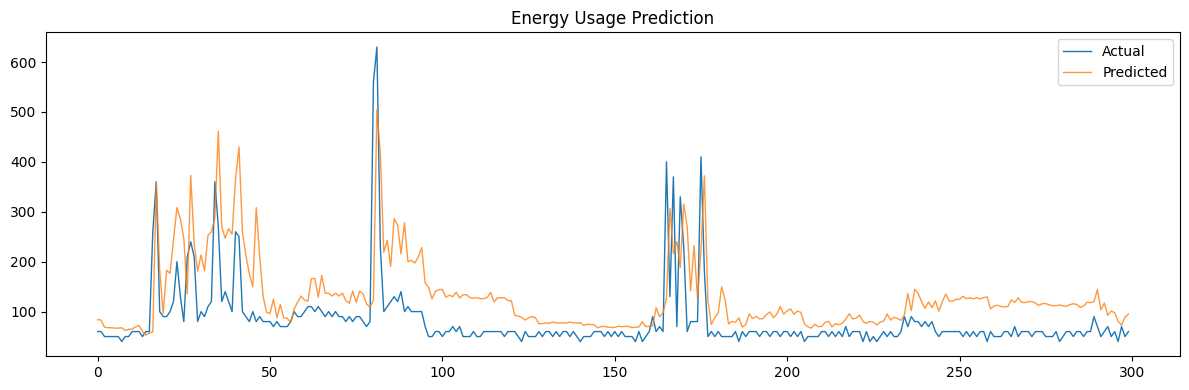

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(ye_test.values[:300], label='Actual', linewidth=1)
plt.plot(xgb_e_pred[:300], label='Predicted', linewidth=1, alpha=0.8)
plt.title('Energy Usage Prediction')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/energy_predictions.png', dpi=100)
plt.show()